In [2]:
import numpy as np
import pandas as pd

# for regression model
from sklearn.linear_model import LogisticRegression
from sklearn import metrics  
from sklearn.metrics import roc_curve, roc_auc_score

# for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import pickle

# import os
# print(os.getcwd())
# os.chdir("C:/Users/Admin/..")
# print(os.getcwd())  # check current directory

# export user-defined functions
%run Userdefined_functions.ipynb

## I. PD Fitting

In [3]:
#loading csv files as pd dataframes
# FOLDER_NAME  = "C:/Users/Admin/..."

# inputs_train = pd.read_csv (FOLDER_NAME +'loan_data_inputs_train.csv',index_col =0).copy()

inputs_train = pd.read_csv ('loan_data_inputs_train.csv',index_col =0).copy()
targets_train = pd.read_csv ('loan_data_targets_train.csv',index_col =0).copy()
inputs_test = pd.read_csv ('loan_data_inputs_test.csv',index_col =0).copy()
targets_test = pd.read_csv ('loan_data_targets_test.csv',index_col =0).copy()

#We have to remove one dummy column for each original variable

In [4]:
inputs_train.columns.values

array(['Age', 'gender', 'occupation', 'month_incom', 'operating_system',
       'phone_provider', 'SHORT_TERM_AMOUNT', 'MID_TERM_AMOUNT',
       'LONG_TERM_AMOUNT', 'SHORT_TERM_COUNT_BANK', 'MID_TERM_COUNT_BANK',
       'LONG_TERM_COUNT_BANK', 'SHORT_TERM_COUNT_NON_BANK',
       'MID_TERM_COUNT_NON_BANK', 'LONG_TERM_COUNT_NON_BANK',
       'NUM_LOANS_BANK', 'NUM_LOANS_NON_BANK', 'NUM_CC_BANK',
       'NUM_CC_NON_BANK', 'NUM_RELATIONSHIP', 'OUTS_BAL_LOAN_M1',
       'OUTS_BAL_CC_M1', 'OUTS_BAL_ALL_M1', 'OUTS_BAL_LOAN_M3',
       'OUTS_BAL_CC_M3', 'OUTS_BAL_ALL_M3', 'OUTS_BAL_LOAN_M6',
       'OUTS_BAL_CC_M6', 'OUTS_BAL_ALL_M6', 'OUTS_BAL_LOAN_M12',
       'OUTS_BAL_CC_M12', 'OUTS_BAL_ALL_M12', 'CC_LIMIT_TOTAL',
       'OUTS_BAL_CC_CURRENT', 'ENQ_3M', 'ENQ_12M', 'NUM_NEW_LOAN_3M',
       'NUM_NEW_LOAN_12M', 'address', 'mths_since_issue_d',
       'BAL_CHANGE_ALL', 'AVG_OUTS_BAL_ALL', 'INCOME_STRESS',
       'occupation:Business_Households', 'occupation:CASUAL_STAFF',
       'occupation:E

In [5]:
inputs_train.head()

,Age,gender,occupation,month_incom,operating_system,phone_provider,SHORT_TERM_AMOUNT,MID_TERM_AMOUNT,LONG_TERM_AMOUNT,SHORT_TERM_COUNT_BANK,...,MID_TERM_AMOUNT:<=36.5,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:<= -181.11,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993,BAL_CHANGE_ALL:>326.993
7103,33.0,FEMALE,OTHER,17000000.0,IOS,viettel,36,391,0,1,...,0,0,0,0,1,0,0,1,0,0
7388,28.0,MALE,WORKER,8000000.0,IOS,viettel,26,0,0,1,...,1,0,0,0,0,0,1,0,0,0
6044,30.0,MALE,OTHER,13000000.0,ANDROID,viettel,16,0,0,0,...,1,0,0,0,0,0,0,1,0,0
418,19.0,MALE,WORKER,5000000.0,IOS,mobifone,3,0,0,1,...,1,0,0,0,0,0,1,0,0,0
4921,20.0,FEMALE,WORKER,9000000.0,0,viettel,19,0,0,2,...,1,0,0,0,0,0,0,1,0,0


In [6]:
# #Example of using Oversampling _ SMOTE

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# # Apply SMOTE
# smote = SMOTE(random_state=42)
# X_res, y_res = smote.fit_resample(X_train, y_train)

# # Train Naive Bayes
# nb = GaussianNB()
# nb.fit(X_res, y_res)

# train_test_split
# → WoE/dummy transform
# → feature selection
# → SMOTE on TRAIN only
# → fit logistic regression

# here maynot need smote
# For PD scorecards:
# Logistic regression without SMOTE is very common
# Try:
# no SMOTE
# SMOTE
# Compare AUC/KS/stability.

# Often no-SMOTE gives more stable/calibrated PDs.

In [87]:
# Here we select a limited set of input variables                                           
features = ['occupation:FARMER_Business_Households_CASUAL_STAFF',
       'occupation:EMPLOYEE_ENGINEER', 'occupation:FREELANCER_STUDENT',
       'occupation:LPAJ_HOUSE_WIFE_ME_MW_R', 'address:ĐB_GL_LD_VL_NT',
       'address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA',
       'address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB',
       'address:HD_HG_PT_BN_DNN_DN',
       'address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB',
       'address:KG_ND_TN_LS', 'address:Rare', 'NUM_CC_BANK:0',
       'NUM_CC_BANK:1', 'NUM_CC_BANK:2', 'NUM_CC_BANK:3-4',
       'NUM_CC_BANK:5-8', 'NUM_CC_BANK:9-18', 'ENQ_3M:1', 'ENQ_3M:2',
       'ENQ_3M:3', 'ENQ_3M:4-5', 'ENQ_3M:6-19', 'ENQ_12M:<=2.38',
       'ENQ_12M:2.38-3.76', 'ENQ_12M:3.76-5.14', 'ENQ_12M:5.14-7.9',
       'ENQ_12M:7.9-12.04', 'ENQ_12M:12.04-18.94', 'ENQ_12M:>18.94',
       'OUTS_BAL_CC_M12:<=4.04', 'OUTS_BAL_CC_M12:4.04-20.2',
       'OUTS_BAL_CC_M12:20.2-36.36', 'OUTS_BAL_CC_M12:36.36-52.52',
       'OUTS_BAL_CC_M12:52.52-80.8', 'OUTS_BAL_CC_M12:>80.8',
       'OUTS_BAL_LOAN_M12:<=17.32', 'OUTS_BAL_LOAN_M12:17.32-51.96',
       'OUTS_BAL_LOAN_M12:51.96-103.92', 'OUTS_BAL_LOAN_M12:103.92-173.2',
       'OUTS_BAL_LOAN_M12:173.2-277.12', 'OUTS_BAL_LOAN_M12:>277.12',
       'OUTS_BAL_CC_M1:<=4.42', 'OUTS_BAL_CC_M1:4.42-17.68',
       'OUTS_BAL_CC_M1:17.68-35.36', 'OUTS_BAL_CC_M1:35.36-70.72',
       'OUTS_BAL_CC_M1:70.72-150.28', 'OUTS_BAL_CC_M1:>150.28',
       'SHORT_TERM_AMOUNT:<=300.08', 'SHORT_TERM_AMOUNT:>300.08',
       'INCOME_STRESS:<=4.37e-06', 'INCOME_STRESS:4.37e-06-1.31e-05',
       'INCOME_STRESS:1.31e-05-3.06e-05',
       'INCOME_STRESS:3.06e-05-8.74e-05', 'INCOME_STRESS:>8.74e-05',
       'MID_TERM_AMOUNT:<=36.5', 'MID_TERM_AMOUNT:36.5-109.5',
       'MID_TERM_AMOUNT:109.5-219.0', 'MID_TERM_AMOUNT:219.0-365.0',
       'MID_TERM_AMOUNT:>365.0', 'BAL_CHANGE_ALL:<= -181.11',
       'BAL_CHANGE_ALL:-181.11 to 14.314',
       'BAL_CHANGE_ALL:14.314 to 92.484',
       'BAL_CHANGE_ALL:92.484 to 326.993'

]

# Here we store the names of the reference category dummy variables in a list.
ref_categories = ['occupation:FARMER_Business_Households_CASUAL_STAFF',
        'address:ĐB_GL_LD_VL_NT',
       'NUM_CC_BANK:0',
       'ENQ_3M:1', 'ENQ_12M:<=2.38',
       'OUTS_BAL_CC_M12:<=4.04',
       'OUTS_BAL_LOAN_M12:<=17.32', 
       'OUTS_BAL_CC_M1:<=4.42',
       'SHORT_TERM_AMOUNT:<=300.08',
       'INCOME_STRESS:<=4.37e-06',
       'MID_TERM_AMOUNT:<=36.5', 
        'BAL_CHANGE_ALL:<= -181.11']

# remove reference categories from features
selected = [x for x in features if x not in ref_categories]

# keep selected columns
inputs_train_ref_categories = inputs_train[selected]
inputs_train_ref_categories.head()

,occupation:EMPLOYEE_ENGINEER,occupation:FREELANCER_STUDENT,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,address:HD_HG_PT_BN_DNN_DN,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,address:KG_ND_TN_LS,address:Rare,NUM_CC_BANK:1,...,INCOME_STRESS:1.31e-05-3.06e-05,INCOME_STRESS:3.06e-05-8.74e-05,INCOME_STRESS:>8.74e-05,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993
7103,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,1,0,1,0
7388,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
6044,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
418,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4921,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# P values for sklearn logistic regression.

# Class to display p-values for logistic regression in sklearn.

from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)
        
        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        #self.z_scores = z_scores
        self.p_values = p_values
        #self.sigma_estimates = sigma_estimates
        #self.F_ij = F_ij

## Model fit after removing some features which are not statistically significant

In [88]:
# Creating an instance from 'LogisticRegression_with_p_values()' class.
reg = LogisticRegression_with_p_values()
# Fitting and obtaining coefs 
reg.fit(inputs_train_ref_categories, targets_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.

# creating a summary table
feature_name = inputs_train_ref_categories.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
# We take the result of the newly added method 'p_values'
p_values = reg.p_values
# Adding the intercept for completeness. We add the value 'NaN' in the beginning of the variable with p-values.
p_values = np.append(np.nan, np.array(p_values))
# Adding a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table['p_values'] = p_values

summary_table

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature name,Coefficients,p_values
0,Intercept,-2.328152,NaN
1,occupation:EMPLOYEE_ENGINEER,-0.277675,4.489183e-03
2,occupation:FREELANCER_STUDENT,-0.515281,5.903851e-06
3,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,-0.537345,7.020544e-01
4,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,0.637336,8.562218e-07
5,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,0.454669,1.052112e-04
6,address:HD_HG_PT_BN_DNN_DN,0.361919,1.476051e-03
7,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,0.083339,4.529458e-01
8,address:KG_ND_TN_LS,-0.246238,3.568629e-01
9,address:Rare,-1.498583,7.134313e-02


In [89]:
# Based on the table, the following variables do not have much statistical significance:

# * mths_since_earliest_cr_line
# * delinq_2yrs
# * open_acc
# * total_acc
# * mths_since_last_delinq
# * mths_since_last_record

## Model fit after removing some features which are not statistically significant

In [90]:
# We are going to remove some features, the coefficients for all or almost all of the dummy variables for which,
# are not tatistically significant.

'''enq 12
cc m12
short term âmt
income stress '''



# We do that by putting them in the comment
# Variables

features = ['occupation:FARMER_Business_Households_CASUAL_STAFF',
       'occupation:EMPLOYEE_ENGINEER', 'occupation:FREELANCER_STUDENT',
       'occupation:LPAJ_HOUSE_WIFE_ME_MW_R', 'address:ĐB_GL_LD_VL_NT',
       'address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA',
       'address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB',
       'address:HD_HG_PT_BN_DNN_DN',
       'address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB',
       'address:KG_ND_TN_LS', 'address:Rare', 'NUM_CC_BANK:0',
       'NUM_CC_BANK:1', 'NUM_CC_BANK:2', 'NUM_CC_BANK:3-4',
       'NUM_CC_BANK:5-8', 'NUM_CC_BANK:9-18', 'ENQ_3M:1', 'ENQ_3M:2',
       'ENQ_3M:3', 'ENQ_3M:4-5', 'ENQ_3M:6-19', 
#         'ENQ_12M:<=2.38',
#        'ENQ_12M:2.38-3.76', 'ENQ_12M:3.76-5.14', 'ENQ_12M:5.14-7.9',
#        'ENQ_12M:7.9-12.04', 'ENQ_12M:12.04-18.94', 'ENQ_12M:>18.94',
#        'OUTS_BAL_CC_M12:<=4.04', 'OUTS_BAL_CC_M12:4.04-20.2',
#        'OUTS_BAL_CC_M12:20.2-36.36', 'OUTS_BAL_CC_M12:36.36-52.52',
#        'OUTS_BAL_CC_M12:52.52-80.8', 'OUTS_BAL_CC_M12:>80.8',
       'OUTS_BAL_LOAN_M12:<=17.32', 'OUTS_BAL_LOAN_M12:17.32-51.96',
       'OUTS_BAL_LOAN_M12:51.96-103.92', 'OUTS_BAL_LOAN_M12:103.92-173.2',
       'OUTS_BAL_LOAN_M12:173.2-277.12', 'OUTS_BAL_LOAN_M12:>277.12',
#        'OUTS_BAL_CC_M1:<=4.42', 'OUTS_BAL_CC_M1:4.42-17.68',
#        'OUTS_BAL_CC_M1:17.68-35.36', 'OUTS_BAL_CC_M1:35.36-70.72',
#        'OUTS_BAL_CC_M1:70.72-150.28', 'OUTS_BAL_CC_M1:>150.28',
# #        'SHORT_TERM_AMOUNT:<=300.08', 'SHORT_TERM_AMOUNT:>300.08',
#        'INCOME_STRESS:<=4.37e-06', 'INCOME_STRESS:4.37e-06-1.31e-05',
#        'INCOME_STRESS:1.31e-05-3.06e-05',
#        'INCOME_STRESS:3.06e-05-8.74e-05', 'INCOME_STRESS:>8.74e-05',
       'MID_TERM_AMOUNT:<=36.5', 'MID_TERM_AMOUNT:36.5-109.5',
       'MID_TERM_AMOUNT:109.5-219.0', 'MID_TERM_AMOUNT:219.0-365.0',
       'MID_TERM_AMOUNT:>365.0', 'BAL_CHANGE_ALL:<= -181.11',
       'BAL_CHANGE_ALL:-181.11 to 14.314',
       'BAL_CHANGE_ALL:14.314 to 92.484',
       'BAL_CHANGE_ALL:92.484 to 326.993'
]

# Here we store the names of the reference category dummy variables in a list.
ref_categories = ['occupation:FARMER_Business_Households_CASUAL_STAFF',
        'address:ĐB_GL_LD_VL_NT',
       'NUM_CC_BANK:0',
       'ENQ_3M:1', 
#                   'ENQ_12M:<=2.38',
#        'OUTS_BAL_CC_M12:<=4.04',
       'OUTS_BAL_LOAN_M12:<=17.32', 
#        'OUTS_BAL_CC_M1:<=4.42',
#        'SHORT_TERM_AMOUNT:<=300.08',
#        'INCOME_STRESS:<=4.37e-06',
       'MID_TERM_AMOUNT:<=36.5', 
        'BAL_CHANGE_ALL:<= -181.11']

# remove reference categories from features
selected = [x for x in features if x not in ref_categories]

# keep selected columns
inputs_train_ref_categories = inputs_train[selected]
inputs_train_ref_categories.head()

,occupation:EMPLOYEE_ENGINEER,occupation:FREELANCER_STUDENT,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,address:HD_HG_PT_BN_DNN_DN,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,address:KG_ND_TN_LS,address:Rare,NUM_CC_BANK:1,...,OUTS_BAL_LOAN_M12:103.92-173.2,OUTS_BAL_LOAN_M12:173.2-277.12,OUTS_BAL_LOAN_M12:>277.12,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993
7103,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,1,0,1,0
7388,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
6044,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
418,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4921,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [91]:
inputs_train_ref_categories.shape

(8959, 30)

In [92]:
targets_train.shape

(8959, 1)

In [93]:
# Here we run a new model.
reg2 = LogisticRegression_with_p_values()
reg2.fit(inputs_train_ref_categories, targets_train)

# Same as above.
feature_name = inputs_train_ref_categories.columns.values
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg2.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

# We add the 'p_values' here, just as we did before.
p_values = reg2.p_values
p_values = np.append(np.nan,np.array(p_values))
summary_table['p_values'] = p_values
summary_table
# Here we get the results for our final PD model.

# Here we export our model to a 'SAV' file with file name 'pd_model.sav'
# pickle.dump(reg2, open('pd_model.sav', 'wb'))

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Feature name,Coefficients,p_values
0,Intercept,-2.295667,NaN
1,occupation:EMPLOYEE_ENGINEER,-0.286954,3.094575e-03
2,occupation:FREELANCER_STUDENT,-0.521095,4.150508e-06
3,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,-0.578278,6.702981e-01
4,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,0.646834,5.296345e-07
5,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,0.456026,9.029907e-05
6,address:HD_HG_PT_BN_DNN_DN,0.349921,2.053706e-03
7,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,0.079279,4.730819e-01
8,address:KG_ND_TN_LS,-0.252665,3.428992e-01
9,address:Rare,-1.483474,7.559265e-02


## II. PD Model Validation on Test Dataset 

In [94]:
#loading df with features refined.   
inputs_test_ref_categories = inputs_test.loc[: , features]

# we drop the variables with reference categories.
inputs_test_ref_categories = inputs_test_ref_categories.drop(ref_categories, axis = 1)
 
inputs_test_ref_categories.head()

,occupation:EMPLOYEE_ENGINEER,occupation:FREELANCER_STUDENT,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,address:QN_BG_LĐ_DT_KH_AG_TTH_BT_PY_TB,address:HD_HG_PT_BN_DNN_DN,address:HB_HY_NA_VP_TH_CT_BD_BRVT_QT_ĐT_LC_NĐ_CB,address:KG_ND_TN_LS,address:Rare,NUM_CC_BANK:1,...,OUTS_BAL_LOAN_M12:103.92-173.2,OUTS_BAL_LOAN_M12:173.2-277.12,OUTS_BAL_LOAN_M12:>277.12,MID_TERM_AMOUNT:36.5-109.5,MID_TERM_AMOUNT:109.5-219.0,MID_TERM_AMOUNT:219.0-365.0,MID_TERM_AMOUNT:>365.0,BAL_CHANGE_ALL:-181.11 to 14.314,BAL_CHANGE_ALL:14.314 to 92.484,BAL_CHANGE_ALL:92.484 to 326.993
8359,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
5523,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1754,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
689,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
10515,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [146]:
y_hat_test = reg2.model.predict(inputs_test_ref_categories)
y_hat_test_proba = reg2.model.predict_proba(inputs_test_ref_categories)[:, 0] # probability of class 0 = GOOD 
#     y_pred = model.predict(X_test)
#     y_prob = model.predict_proba(X_test)[:, 1]

targets_test_temp = targets_test
targets_test_temp.reset_index(drop=True, inplace=True)

df_actual_predicted_probs = pd.concat([targets_test_temp, pd.DataFrame(y_hat_test_proba)], axis=1)
df_actual_predicted_probs.columns = ['targets_test', 'y_hat_test_proba']
df_actual_predicted_probs.index = inputs_test.index
df_actual_predicted_probs.head()

,targets_test,y_hat_test_proba
8359,0,0.954167
5523,0,0.866177
1754,0,0.942617
689,0,0.913630
10515,0,0.963354


In [147]:
X_test = inputs_test_ref_categories
y_test = targets_test
y_pred =  reg2.model.predict(X_test)
y_prob =  reg2.model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
gini = 2 * roc_auc - 1
gini

#not work
# def ks_stat(y_true, y_prob):
#     df = pd.DataFrame({
#         'y': y_true,
#         'p': y_prob
#     }).sort_values('p')
#     bad = (df['y'] == 1).astype(int)
#     good = (df['y'] == 0).astype(int)
#     cum_bad = bad.cumsum() / bad.sum()
#     cum_good = good.cumsum() / good.sum()
#     ks = np.max(np.abs(cum_bad - cum_good))
#     return ks
# ks = ks_stat(y_test, y_prob)

0.3055078233143358

In [148]:
# ── Threshold & Confusion Matrix ──────────────────────────────────────────────
tr = 0.9
# CHANGED: prob > tr means likely GOOD (0), so predict 0
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba'] > tr, 0, 1)

confusion_matrix = pd.crosstab(df_actual_predicted_probs['targets_test'],
                                df_actual_predicted_probs['y_hat_test'],
                                rownames=['Actual'], colnames=['Predicted'])
confusion_matrix

Predicted,0,1
Actual,,
0,1330,704
1,87,119


In [149]:
confusionm_perc = confusion_matrix / df_actual_predicted_probs.shape[0]
confusionm_perc

TN = confusionm_perc.iloc[0, 0]  # true negative (predicted good=0, actual good=0)
TP = confusionm_perc.iloc[1, 1]  # true positive (predicted bad=1, actual bad=1)
print('Accuracy on test dataset=', round(TN + TP, 4))

Accuracy on test dataset= 0.6469


Text(0.5, 1.0, 'ROC curve')

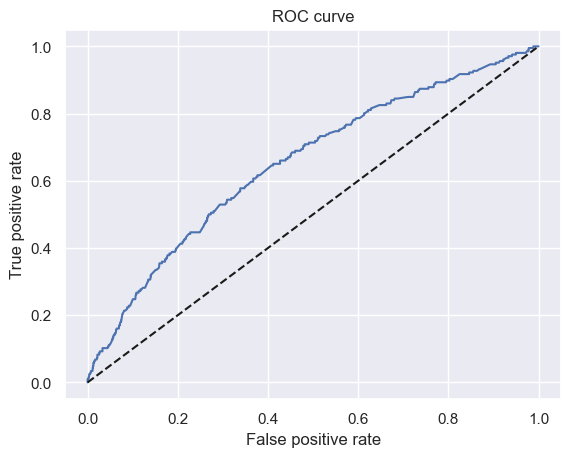

In [150]:
# ── ROC / AUROC ───────────────────────────────────────────────────────────────
# roc_curve expects higher score = more likely POSITIVE (bad=1 in your data)
# so pass 1 - proba (probability of being bad) as the score
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['targets_test'],
                                  1 - df_actual_predicted_probs['y_hat_test_proba'])  # CHANGED
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle='--', color='k')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [18]:
AUROC = roc_auc_score(df_actual_predicted_probs['targets_test'],
                      1 - df_actual_predicted_probs['y_hat_test_proba'])  #####
AUROC

0.6527539116571679

In [19]:
# ── Gini & KS ─────────────────────────────────────────────────────────────────
# Sort ascending by prob of good (lowest prob of good = most likely bad = riskiest)
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

df_actual_predicted_probs['Cum N Population'] = df_actual_predicted_probs.index + 1

####: cumsum of targets_test now counts BADs (1=bad), not Goods
df_actual_predicted_probs['Cum N Bad']  = df_actual_predicted_probs['targets_test'].cumsum()
df_actual_predicted_probs['Cum N Good'] = df_actual_predicted_probs['Cum N Population'] \
                                         - df_actual_predicted_probs['Cum N Bad']

sum_all  = df_actual_predicted_probs.shape[0]
df_actual_predicted_probs['Cum Perc Population'] = df_actual_predicted_probs['Cum N Population'] / sum_all

# CHANGED: sum of targets_test = total bads
sum_bad  = df_actual_predicted_probs['targets_test'].sum()
sum_good = sum_all - sum_bad

df_actual_predicted_probs['Cum Perc Bad']  = df_actual_predicted_probs['Cum N Bad']  / sum_bad
df_actual_predicted_probs['Cum Perc Good'] = df_actual_predicted_probs['Cum N Good'] / sum_good

0.3055078233143358

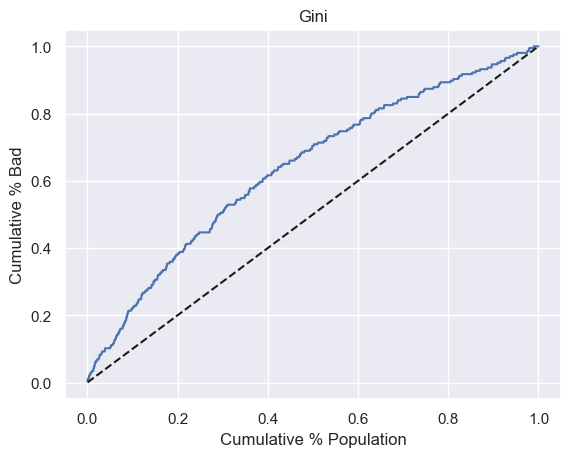

In [20]:
# Gini
plt.plot(df_actual_predicted_probs['Cum Perc Population'], df_actual_predicted_probs['Cum Perc Bad'])
plt.plot(df_actual_predicted_probs['Cum Perc Population'], df_actual_predicted_probs['Cum Perc Population'], linestyle='--', color='k')
plt.xlabel('Cumulative % Population')
plt.ylabel('Cumulative % Bad')
plt.title('Gini')

Gini = AUROC * 2 - 1
Gini

0.2405323099540816

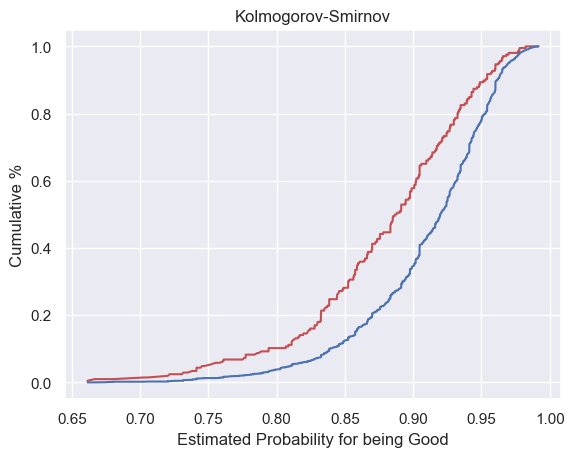

In [21]:
# KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cum Perc Bad'],  color='r')
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cum Perc Good'], color='b')
plt.xlabel('Estimated Probability for being Good')  # CHANGED (label still correct: x = prob of good)
plt.ylabel('Cumulative %')
plt.title('Kolmogorov-Smirnov')

KS = max(df_actual_predicted_probs['Cum Perc Bad'] - df_actual_predicted_probs['Cum Perc Good'])
KS

### SCORRCARD

In [127]:
df_ref_categories = pd.DataFrame(ref_categories,columns = ['Feature name'])
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan

df_scorecard = pd.concat ([summary_table, df_ref_categories ])
df_scorecard = df_scorecard.reset_index()

df_scorecard['Original feature name'] = df_scorecard['Feature name'].str.split(':').str[0]
df_scorecard.head()

,index,Feature name,Coefficients,p_values,Original feature name
0,0,Intercept,-2.295667,NaN,Intercept
1,1,occupation:EMPLOYEE_ENGINEER,-0.286954,3.094575e-03,occupation
2,2,occupation:FREELANCER_STUDENT,-0.521095,4.150508e-06,occupation
3,3,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,-0.578278,6.702981e-01,occupation
4,4,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,0.646834,5.296345e-07,address


In [106]:
df_scorecard.shape

(38, 5)

In [129]:
#fix minimum score of 300 and max score of 850
min_score = 300
max_score = 850

max_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].max().sum()
min_sum_coef = df_scorecard.groupby('Original feature name')['Coefficients'].min().sum()
ratio_ = (max_score-min_score) / (max_sum_coef - min_sum_coef)
#calculating scores from coefs
df_scorecard.loc[:,'Score - Calculation'] = (df_scorecard.loc[:,'Coefficients'] * ratio_).round()
#replacing intercept coef
df_scorecard.loc[0,'Score - Calculation'] = ((df_scorecard.loc[0,'Coefficients'] - min_sum_coef)*ratio_+ min_score ).round()
df_scorecard.head()

,index,Feature name,Coefficients,p_values,Original feature name,Score - Calculation
0,0,Intercept,-2.295667,NaN,Intercept,681.0
1,1,occupation:EMPLOYEE_ENGINEER,-0.286954,3.094575e-03,occupation,-24.0
2,2,occupation:FREELANCER_STUDENT,-0.521095,4.150508e-06,occupation,-44.0
3,3,occupation:LPAJ_HOUSE_WIFE_ME_MW_R,-0.578278,6.702981e-01,occupation,-49.0
4,4,address:BĐ_TG_QB_ĐL_TV_NB_BP_BL_LA,0.646834,5.296345e-07,address,55.0


In [130]:
#check if we have min score of 300 and max score of 850
min_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Calculation'].min().sum()
max_sum_score_prel = df_scorecard.groupby('Original feature name')['Score - Calculation'].max().sum()
print(min_sum_score_prel, max_sum_score_prel)

300.0 850.0


In [132]:
# test dataset with reference categories
inputs_test_with_ref_cat_w_intercept = inputs_test.loc[: , features]
# inserting the intercept point w an index of 0, that is, in the beginning of df
# The name of that column is 'Intercept', and its values are 1s.
inputs_test_with_ref_cat_w_intercept.insert(0,'Intercept', 1)
# ensuring that we selected the same features used in scorecard 
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept [df_scorecard['Feature name'].values]
# inputs_test_with_ref_cat_w_intercept.shape

#creating the score card array
scorecard_scores = df_scorecard['Score - Calculation']
scorecard_scores.shape

(38,)

In [133]:
scorecard_scores = scorecard_scores.values.reshape(38,1) #from list to an array
# multiplying the values of each row of the dataframe by the values of each column of the variable,
# with 'dot' method (sum of the products)
y_scores = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)
y_scores

,0
8359,618.0
5523,717.0
1754,638.0
689,676.0
10515,600.0
...,...
8950,596.0
10472,643.0
9101,685.0
3546,705.0


In [134]:
#Assign risk tiers (Higher Score = Lower Risk)
risk_labels = ['Very High', 'High', 'Medium', 'Low', 'Very Low']
df = y_scores.copy()
df.columns = ['Score']
df['Risk_Tier'] = pd.qcut(df['Score'], q=5, labels=risk_labels)

#View results and the score ranges for each tier
df.head()

,Score,Risk_Tier
8359,618.0,Very High
5523,717.0,Low
1754,638.0,High
689,676.0,Medium
10515,600.0,Very High


In [139]:
y_hat_test_proba[0:5] #we see that the score is algin with prob ..: high score = low 

array([0.95416689, 0.86617737, 0.94261675, 0.91363011, 0.96335415])

In [135]:
print("\nScore Ranges per Tier:")
print(df.groupby('Risk_Tier', observed=False)['Score'].agg(['min', 'max']))


Score Ranges per Tier:
             min    max
Risk_Tier              
Very High  471.0  625.0
High       626.0  657.0
Medium     658.0  685.0
Low        686.0  717.0
Very Low   718.0  818.0


In [136]:
# Dividing the difference b/w the scores and the minimum score by diff b/w max and min score.
# Multiplying by the diff b/w max sum of coefs and min sum of coefs.
# Adding minimum sum of coefs.
coef_ =   (max_sum_coef - min_sum_coef) / (max_score - min_score) 
sum_coef_from_score = (y_scores - min_score) * coef_ + min_sum_coef
# dividing an exponent raised to sum of coefs from score by
# an exponent raised to sum of coefs from score plus one.
y_hat_proba_from_score = np.exp(sum_coef_from_score) / (np.exp(sum_coef_from_score) + 1)
y_hat_proba_from_score.head() # = 1- prob of being 

,0
8359,0.045603
5523,0.133884
1754,0.057112
689,0.086806
10515,0.037163


In [137]:
y_hat_proba_from_score.shape

(2240, 1)

In [138]:
y_hat_test_proba[0:5] #we see that y test proba is correct : check ...from score and ... (sum up =1 )

array([0.95416689, 0.86617737, 0.94261675, 0.91363011, 0.96335415])